# DeepShield Detect - Environment Setup & Dataset Preparation

**Project**: Deepfake Detection with Deep Learning  
**Tech Stack**: TensorFlow 2.13, EfficientNet-B4, Gradio  
**Dataset**: 140k Real and Fake Faces (Kaggle)

This notebook:
-  Verifies the development environment
-  Validates dataset structure
-  Prepares training data (real vs fake images)

## 1. Environment Verification
Check if all required libraries are installed and GPU is available.

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import gradio as gr
from mtcnn import MTCNN

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"OpenCV     : {cv2.__version__}")
print(f"GPU dispo  : {len(tf.config.list_physical_devices('GPU')) > 0}")
print("Tout est OK ! Environnement prêt.")

c:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow : 2.21.0
NumPy      : 2.4.4
OpenCV     : 4.13.0
GPU dispo  : False
Tout est OK ! Environnement prêt.


##  Dataset Structure Verification

This section verifies that the dataset has been correctly organized with real and fake images in their respective folders.

In [1]:
from pathlib import Path
from collections import Counter

# Define paths
BASE_DIR = Path(r"C:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect")
DATA_REAL = BASE_DIR / "data" / "real"
DATA_FAKE = BASE_DIR / "data" / "fake"

print("=" * 60)
print(" DATASET STRUCTURE VERIFICATION")
print("=" * 60)

# Check if directories exist
print(f"\n Real images folder: {DATA_REAL}")
print(f"   Exists: {DATA_REAL.exists()}")

print(f"\n Fake images folder: {DATA_FAKE}")
print(f"   Exists: {DATA_FAKE.exists()}")

# Count files by extension
def analyze_folder(folder_path, label):
    if folder_path.exists():
        files = list(folder_path.iterdir())
        extensions = Counter(f.suffix.lower() for f in files if f.is_file())
        
        print(f"\n {label} folder analysis:")
        print(f"   Total files: {len(files)}")
        print(f"   Extensions: {dict(extensions)}")
        
        # Check for valid image extensions
        valid_ext = {'.jpg', '.jpeg', '.png', '.bmp'}
        valid_files = [f for f in files if f.suffix.lower() in valid_ext]
        print(f"   Valid images: {len(valid_files)}")
        
        return len(valid_files)
    else:
        print(f"    Folder not found!")
        return 0

real_count = analyze_folder(DATA_REAL, "REAL")
fake_count = analyze_folder(DATA_FAKE, "FAKE")

print("\n" + "=" * 60)
if real_count > 0 and fake_count > 0:
    print(" DATASET READY FOR TRAINING")
else:
    print(" DATASET INCOMPLETE - Please check your data folders")
print("=" * 60)

 DATASET STRUCTURE VERIFICATION

 Real images folder: C:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\data\real
   Exists: True

 Fake images folder: C:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\data\fake
   Exists: True

 REAL folder analysis:
   Total files: 5001
   Extensions: {'.jpg': 5000}
   Valid images: 5000

 FAKE folder analysis:
   Total files: 5000
   Extensions: {'.jpg': 5000}
   Valid images: 5000

 DATASET READY FOR TRAINING




Once environment and dataset are verified, proceed to:
1. **01_exploration.ipynb** - Dataset visualization and analysis
2. **02_preprocessing.ipynb** - Face detection and preprocessing
3. **03_model_building.ipynb** - EfficientNet-B4 model construction
4. **04_training.ipynb** - Model training and validation

# Dataset Exploration and Validation
## Visual Analysis of Real vs Fake Faces

 Real images  : 5000
 Fake images  : 5000


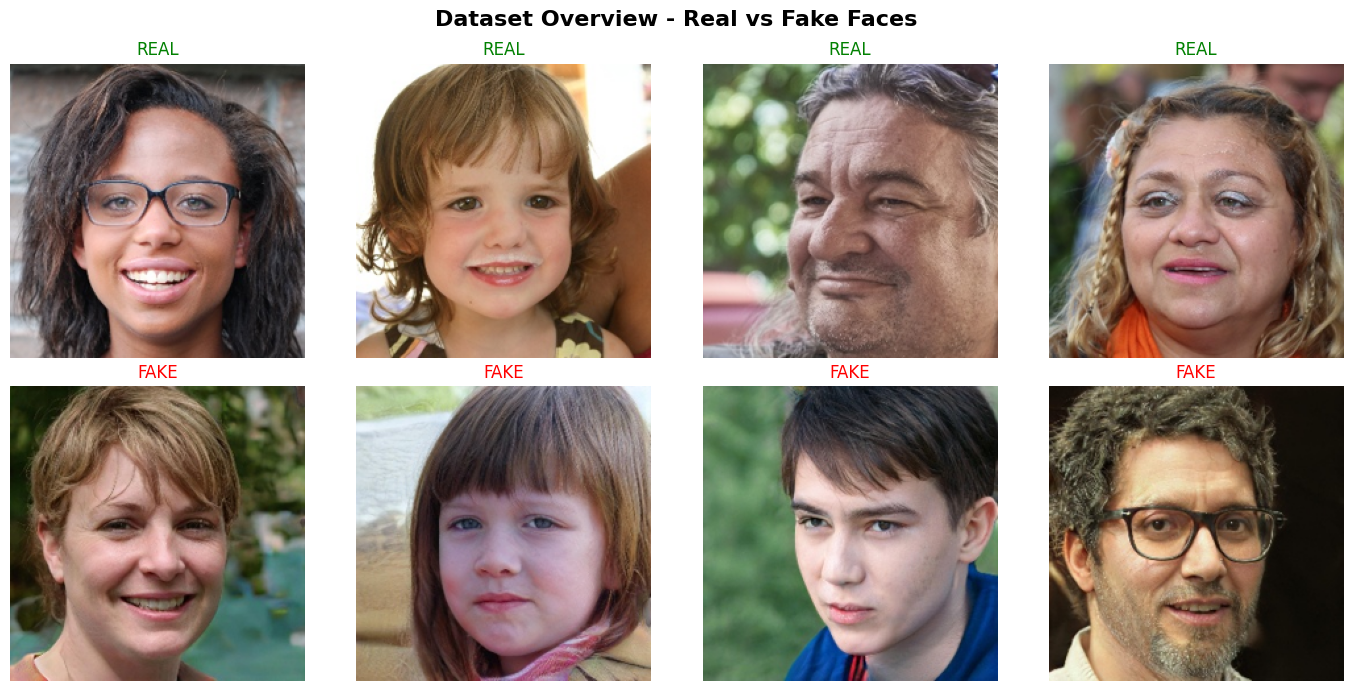


 Overview saved to: C:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\results\dataset_overview.png


In [3]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Define paths
BASE_DIR = Path(r"C:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect")
DATA_REAL = BASE_DIR / "data" / "real"
DATA_FAKE = BASE_DIR / "data" / "fake"

# Get image lists
real_imgs = [f'data/real/{f.name}' for f in DATA_REAL.iterdir() if f.suffix.lower() == '.jpg']
fake_imgs = [f'data/fake/{f.name}' for f in DATA_FAKE.iterdir() if f.suffix.lower() == '.jpg']

print(f' Real images  : {len(real_imgs)}')
print(f' Fake images  : {len(fake_imgs)}')

# Display sample images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Display 4 real images
for i, ax in enumerate(axes[0]):
    img_path = random.choice(real_imgs)
    img = Image.open(BASE_DIR / img_path).resize((224, 224))
    ax.imshow(img)
    ax.set_title('REAL', color='green', fontsize=12)
    ax.axis('off')

# Display 4 fake images
for i, ax in enumerate(axes[1]):
    img_path = random.choice(fake_imgs)
    img = Image.open(BASE_DIR / img_path).resize((224, 224))
    ax.imshow(img)
    ax.set_title('FAKE', color='red', fontsize=12)
    ax.axis('off')

plt.suptitle('Dataset Overview - Real vs Fake Faces', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save result
results_dir = BASE_DIR / "results"
results_dir.mkdir(exist_ok=True)
plt.savefig(results_dir / "dataset_overview.png", dpi=150)
plt.show()

print(f"\n Overview saved to: {results_dir / 'dataset_overview.png'}")